In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Indian Population Dataset.xlsx to Indian Population Dataset.xlsx


In [3]:
import pandas as pd

df = pd.read_excel("Indian Population Dataset.xlsx")
df.head()

,State,Region,Population,Area_km2,Literacy_Rate,Density
0,Karnataka,South,67562686,191791,75.86,834
1,Tamil Nadu,South,72147030,130058,24.56,349
2,Kerala,South,35699443,38863,21.66,245
3,Maharashtra,West,124904071,307713,90.97,653
4,Delhi,North,16787941,1484,78.09,765


In [4]:
df.isnull().sum()

,0
State,0
Region,0
Population,0
Area_km2,0
Literacy_Rate,0
Density,0


In [5]:
X = df.drop("Population", axis=1)
y = df["Population"]

In [6]:
X = pd.get_dummies(X, columns=["State", "Region"], drop_first=True)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [9]:
print("Intercept:")
print(lr.intercept_)

print("\nCoefficients:")

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef

Intercept:
5906538.0538578555

Coefficients:


,Feature,Coefficient
0,Area_km2,1.779073e+02
1,Literacy_Rate,6.395078e+05
2,Density,-3.022893e+04
3,State_Delhi,-2.349676e+06
4,State_Gujarat,-1.255959e+07
5,State_Karnataka,-2.655757e+06
6,State_Kerala,9.544498e+06
7,State_Maharashtra,1.918809e+07
8,State_Rajasthan,-1.149730e+07
9,State_Tamil Nadu,0.000000e+00


In [10]:
y_pred = lr.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("Mean Absolute Error :", mae)

print("R² Score :", r2)

Mean Squared Error : 1.5079698722910192e+16
Root Mean Squared Error : 122799424.76620236
Mean Absolute Error : 100961043.09128924
R² Score : -2.700895659832851


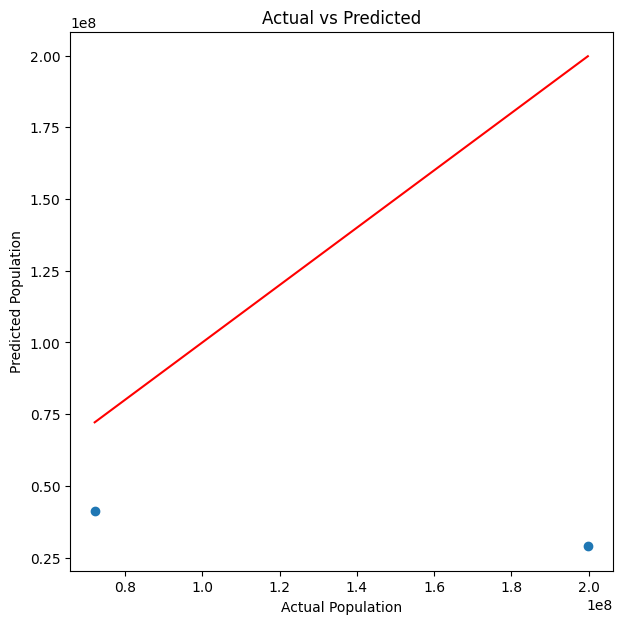

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Population")

plt.ylabel("Predicted Population")

plt.title("Actual vs Predicted")

plt.show()

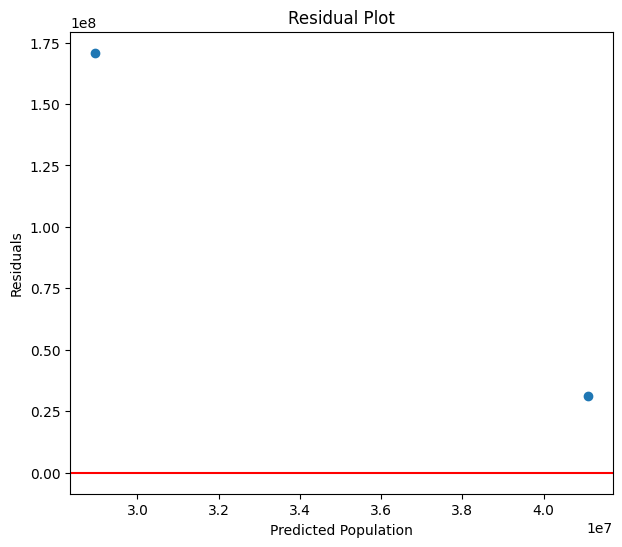

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(7,6))

plt.scatter(y_pred, residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted Population")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [14]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [15]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [16]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "MSE":[
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],

    "MAE":[
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],

    "R2 Score":[
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]

})

results

,Model,MSE,RMSE,MAE,R2 Score
0,Linear Regression,1.507970e+16,1.227994e+08,1.009610e+08,-2.700896
1,Ridge Regression,1.042586e+16,1.021071e+08,8.336710e+07,-1.558740
2,Lasso Regression,9.821672e+15,9.910435e+07,8.197878e+07,-1.410458
